In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [ ]:





df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


df['Year'] = df['Order Date'].dt.year

df = df.dropna(subset=['Year'])


df['Year'] = df['Year'].astype(int)


yearly_sales = df.groupby('Year')['Sales'].sum().sort_index()

print("Yearly Revenue:")
print(yearly_sales)

#  Calculate Growth Percentage
yearly_growth = yearly_sales.pct_change() * 100

print("\nYearly Growth %:")
print(yearly_growth)



Yearly Revenue:
Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Yearly Growth %:
Year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64


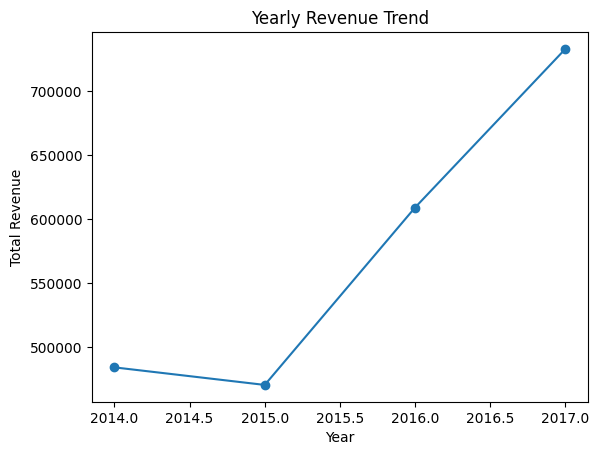

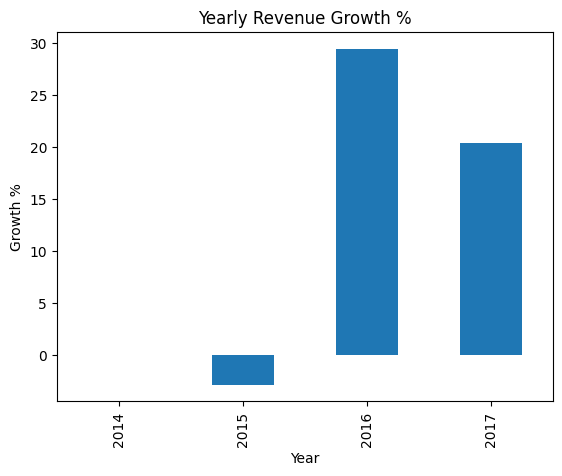


Highest Revenue Year: 2017
Revenue: 733215.2552


In [ ]:

plt.figure()
yearly_sales.plot(kind='line', marker='o')
plt.title("Yearly Revenue Trend")
plt.ylabel("Total Revenue")
plt.xlabel("Year")
plt.show()


plt.figure()
yearly_growth.plot(kind='bar')
plt.title("Yearly Revenue Growth %")
plt.ylabel("Growth %")
plt.xlabel("Year")
plt.show()

# q1-- Find Highest Revenue Year
highest_year = yearly_sales.idxmax()
highest_value = yearly_sales.max()

print(f"\nHighest Revenue Year: {highest_year}")
print(f"Revenue: {highest_value}")

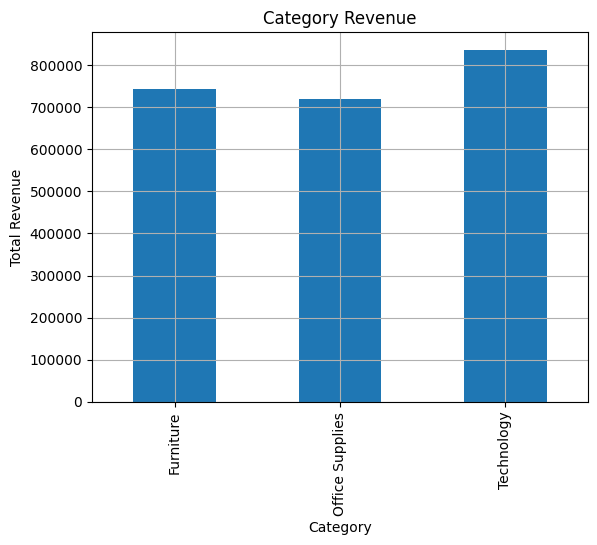

In [ ]:
#q2--Which Category Generates Highest Revenue?
Category_sales=df.groupby('Category')['Sales'].sum()
Category_sales.plot(kind='bar')
plt.grid()
plt.title("Category Revenue")
plt.ylabel("Total Revenue")
plt.xlabel("Category")
plt.show()

In [ ]:
#q2--Which Category Generates Highest Profit?

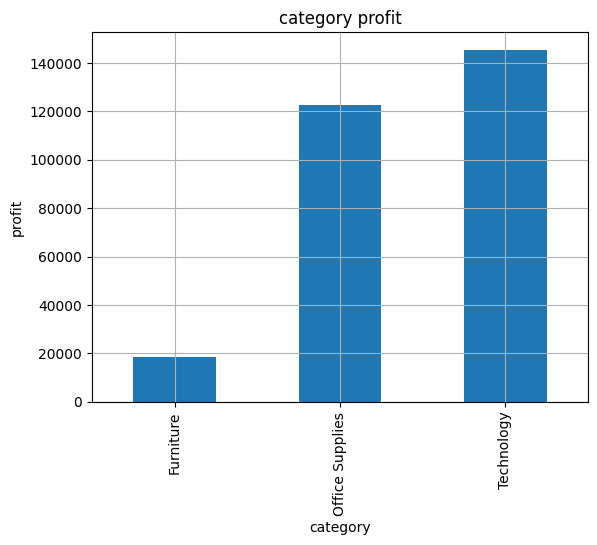

In [ ]:
highest_categoryproft=df.groupby('Category')['Profit'].sum()
highest_categoryproft.plot(kind='bar')
plt.grid()
plt.title('category profit')
plt.ylabel('profit')
plt.xlabel('category')
plt.show()

# New Section

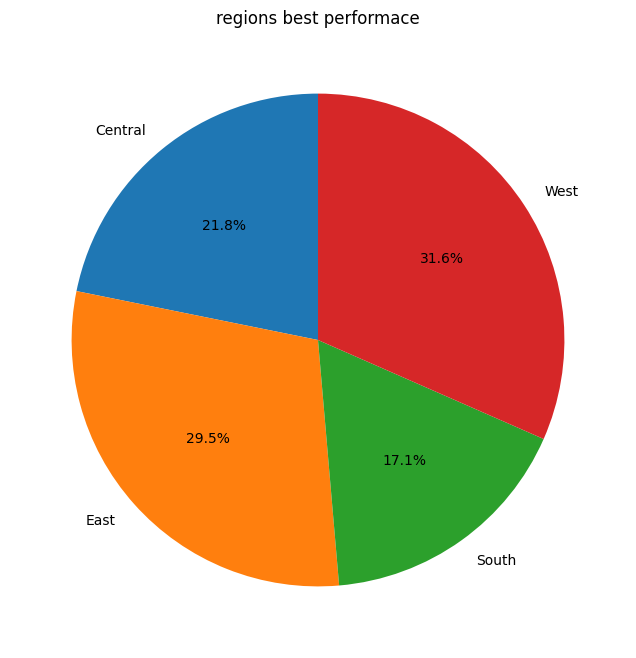

In [ ]:
#qno4 Which Region Performs Best?
best_region=df.groupby('Region')['Sales'].sum()
best_region.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(8,8), labels=best_region.index)
plt.title('regions best performace')
plt.ylabel('')
plt.show()

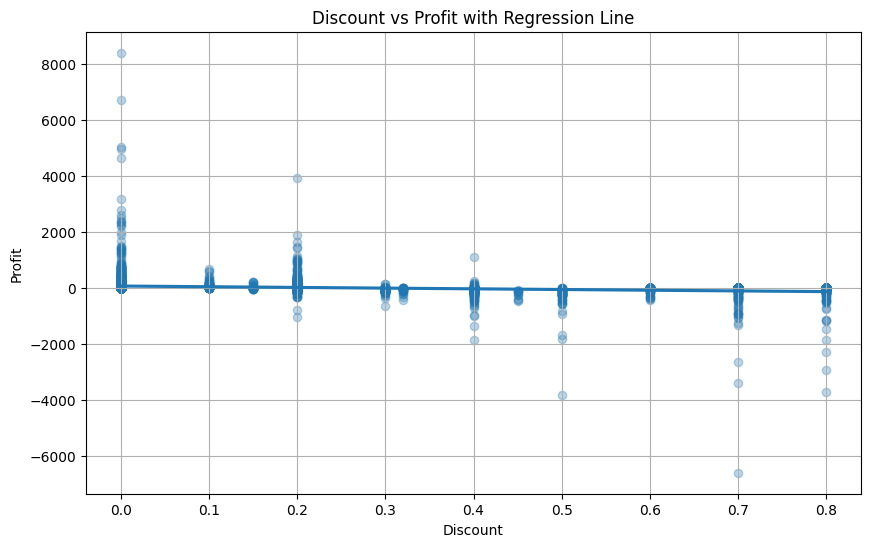

In [ ]:
import seaborn as sns

#qno2 Are Discounts Hurting Profit?
#is discount effect the profit margine
plt.figure(figsize=(10, 6))
sns.regplot(x='Discount', y='Profit', data=df, scatter_kws={'alpha':0.3})
plt.title('Discount vs Profit with Regression Line')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64


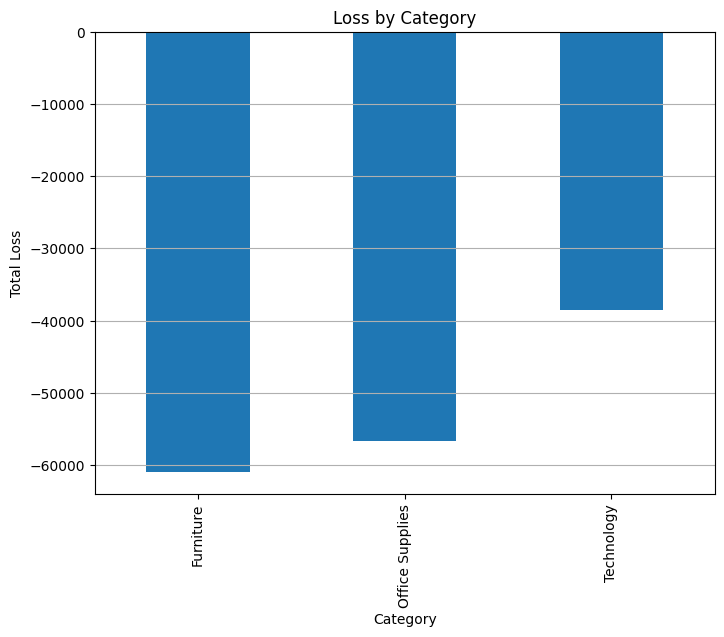

In [ ]:
#qno6 Which Products Are Causing Loss?
loss_products = df[df['Profit'] < 0]
loss=loss_products.groupby('Category')['Profit'].sum()
print(loss)
# Use a bar plot instead of a pie chart to visualize negative values
loss.plot(kind='bar', figsize=(8,6))
plt.title('Loss by Category')
plt.ylabel('Total Loss')
plt.xlabel('Category')
plt.grid(axis='y')
plt.show()

<Axes: ylabel='Profit'>

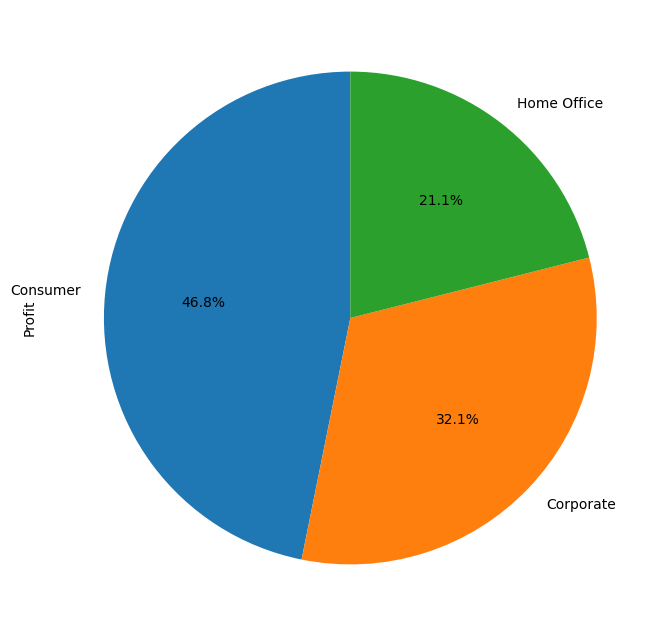

In [ ]:
#qno7
customer_segement=df.groupby('Segment')['Profit'].sum()
customer_segement.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(8,8),labels=customer_segement.index)